# Rapport visuel — Pipeline Texte + Images



## Diagramme du pipeline (vue d'ensemble)

```
Données brutes
   ├─ Texte (designation, description)
   │    ├─ Nettoyage (HTML→remove, lower, ponctuation, stopwords, mots vagues, stemming, traduction map)
   │    ├─ Features simples (has_description, designation_length)
   │    └─ TF-IDF (1-2 grams)
   ├─ Images (image_{imageid}_product_{productid}.jpg)
   │    ├─ Resize (H×W), RGB
   │    ├─ Normalisation [0,1]
   │    └─ Stats objet (width, height, occupancy)
   └─ Fusion
        └─ FeatureUnion([texte, image_pixels, image_stats])
             → StandardScaler(with_mean=False) → Sampling (Under/Over) → Modèle (LR / LinearSVC)
             → Évaluation / Prédiction
```


## 0) Bootstrapping import (assure l'accès au package `features`)

In [3]:
import sys
from pathlib import Path
import os
os.chdir("..")

ROOT = Path.cwd()  # suppose que le notebook est lancé depuis la racine du repo
# Fallback: si on détecte qu'on est dans notebooks/, on ajoute le parent
if (ROOT.name == 'notebooks'):
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('PYTHONPATH bootstrapped ->', ROOT)

PYTHONPATH bootstrapped -> c:\Users\julie\Desktop\jul25_bootcamp_ds_classification-de-produits-e--commerce-rakuten-main


## 1) Chargement configuration & données

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np

# Lecture du TOML (Py≥3.11: tomllib ; sinon tomli)
try:
    import tomllib  # Python 3.11+
except ModuleNotFoundError:
    import tomli as tomllib

# Détecte la racine du repo même si on lance depuis notebooks/
CWD = Path.cwd()
ROOT = CWD if (CWD / "features").exists() else CWD.parent
# Liste de candidats (ordre de priorité)
CANDIDATES = [
    ROOT / "features" / "config.toml",
    ROOT / "config.toml",
    Path("../features/config.toml"),
    Path("features/config.toml"),
]

cfg = None
picked = None
for p in CANDIDATES:
    if p.exists():
        with open(p, "rb") as f:
            cfg = tomllib.load(f)
        picked = p
        print(f"[ok] Config chargée : {p}")
        break

if cfg is None:
    raise FileNotFoundError(
        "Aucun config.toml trouvé. Chemins testés :\n" + "\n".join(map(str, CANDIDATES))
    )

paths = cfg.get("paths", {})
text_cfg = cfg.get("text", {})
images_cfg = cfg.get("images", {})

X_train_path = paths.get("x_train_csv", "data/X_train_update.csv")
y_train_path = paths.get("y_train_csv", "data/Y_train_update.csv")

X_train = pd.read_csv(ROOT / X_train_path, index_col=0)
y_train = pd.read_csv(ROOT / y_train_path, index_col=0).squeeze() if (ROOT / y_train_path).exists() else None
print(f"[ok] X_train: {X_train.shape} | y_train: {None if y_train is None else y_train.shape}")
X_train.head(3)

[ok] Config chargée : c:\Users\julie\Desktop\jul25_bootcamp_ds_classification-de-produits-e--commerce-rakuten-main\features\config.toml
[ok] X_train: (84916, 4) | y_train: (84916,)


,designation,description,productid,imageid
0,Olivia: Personalisiertes Notizbuch / 150 Seite...,NaN,3804725264,1263597046
1,Journal Des Arts (Le) N° 133 Du 28/09/2001 - L...,NaN,436067568,1008141237
2,Grand Stylet Ergonomique Bleu Gamepad Nintendo...,PILOT STYLE Touch Pen de marque Speedlink est ...,201115110,938777978


## 2) Texte — Longueur avant / après nettoyage

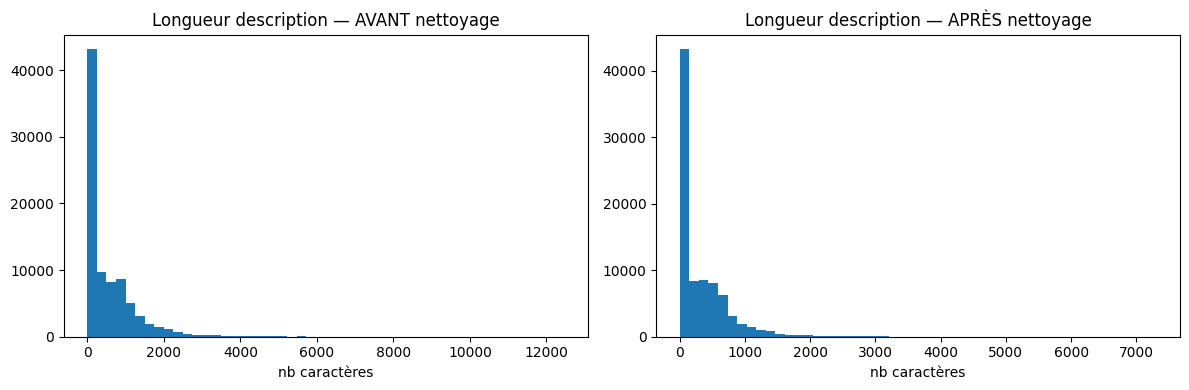

In [8]:
import matplotlib.pyplot as plt
from features.text_cleaner import TextCleaner

tc = TextCleaner(
    remove_html=True,
    translate_map={},   # laisser vide ici; chargé automatiquement dans la branche pipeline
    use_stem=bool(text_cfg.get('use_stem', True))
)

# Avant: longueur brute de description (NaN→"")
desc_raw = X_train['description'].fillna('').astype(str)
len_raw = desc_raw.str.len()

# Après: longueur du texte nettoyé (on applique le clean_text sur la description seule)
len_clean = desc_raw.map(tc.clean_text).str.len()

fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(len_raw, bins=50)
axes[0].set_title('Longueur description — AVANT nettoyage')
axes[0].set_xlabel('nb caractères')

axes[1].hist(len_clean, bins=50)
axes[1].set_title('Longueur description — APRÈS nettoyage')
axes[1].set_xlabel('nb caractères')
plt.tight_layout()
plt.show()

## 3) Texte — Fréquences de tokens (proxy Wordcloud)

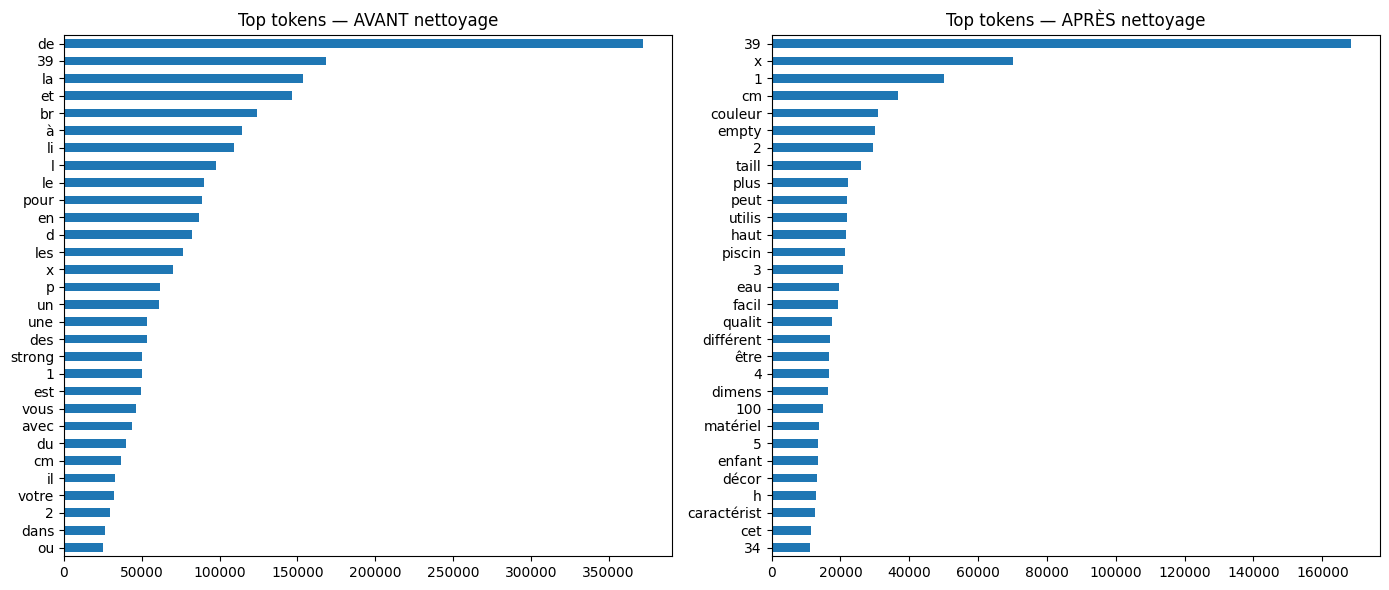

In [9]:
import re, string
from collections import Counter

import pandas as pd

def basic_normalize(s: str) -> str:
    s = s.lower()
    s = re.sub(f"[{re.escape(string.punctuation)}]", ' ', s)
    s = re.sub(r"\s+", ' ', s).strip()
    return s

def top_tokens(series, topk=30):
    c = Counter()
    for line in series:
        for t in basic_normalize(line).split():
            c[t] += 1
    return pd.Series(dict(c.most_common(topk)))

top_raw = top_tokens(desc_raw, 30)
top_clean = top_tokens(desc_raw.map(tc.clean_text), 30)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
top_raw.sort_values().plot(kind='barh', ax=axes[0])
axes[0].set_title('Top tokens — AVANT nettoyage')
top_clean.sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('Top tokens — APRÈS nettoyage')
plt.tight_layout()
plt.show()

## 4) Images — Exemples avant / après resize + normalisation

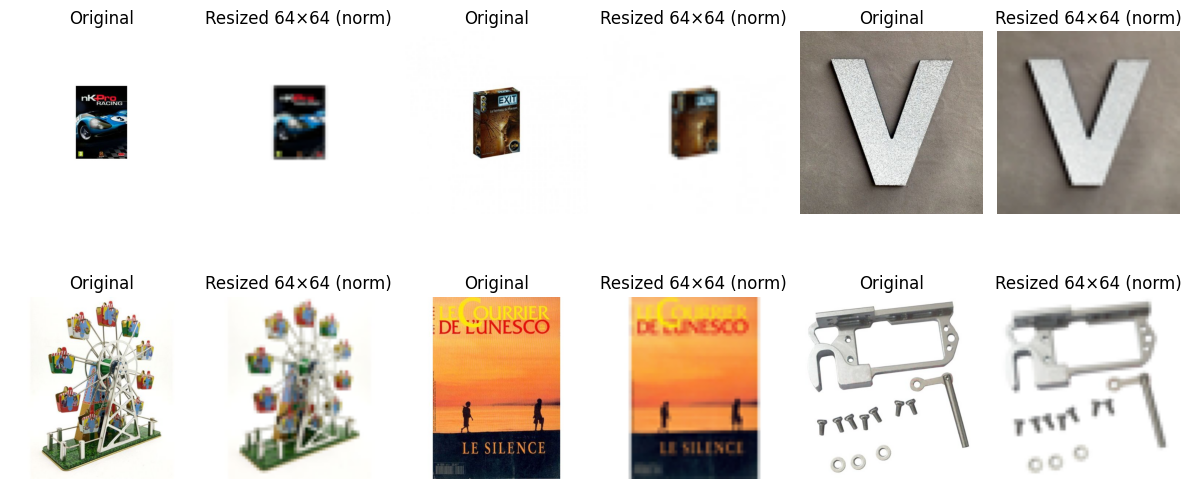

In [10]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

img_dir = images_cfg.get('train_dir', 'data/images/train')
size = images_cfg.get('size', [64,64])
H, W = size[0], size[1]

def path_for(row):
    # Patron Rakuten: image_{imageid}_product_{productid}.jpg
    return Path(img_dir) / f"image_{int(row['imageid'])}_product_{int(row['productid'])}.jpg"

def load_original(path):
    with Image.open(path) as im:
        return np.asarray(im.convert('RGB'))  # 0..255, (H,W,3)

def load_resized_norm(path, size=(H,W)):
    with Image.open(path) as im:
        im = im.convert('RGB').resize((W, H))
        arr = np.asarray(im, dtype=np.float32) / 255.0
        return arr

sample = X_train.dropna(subset=['imageid']).sample(n=min(6, len(X_train.dropna(subset=['imageid']))), random_state=42)
n = len(sample)
if n > 0:
    cols = 3
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols*2, figsize=(cols*4, rows*3))
    axes = np.atleast_2d(axes)

    for i, (_, row) in enumerate(sample.iterrows()):
        p = path_for(row)
        ax1 = axes[i//(cols)][(i%cols)*2]
        ax2 = axes[i//(cols)][(i%cols)*2 + 1]
        try:
            orig = load_original(p)
            resz = load_resized_norm(p, (H,W))
            ax1.imshow(orig); ax1.set_title('Original'); ax1.axis('off')
            ax2.imshow(resz); ax2.set_title(f'Resized {H}×{W} (norm)'); ax2.axis('off')
        except Exception as e:
            ax1.set_title('manquante'); ax1.axis('off')
            ax2.set_title('manquante'); ax2.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Aucun échantillon image affichable (imageid manquant).')

## 5) Images — Boxplot des valeurs RGB avant / après

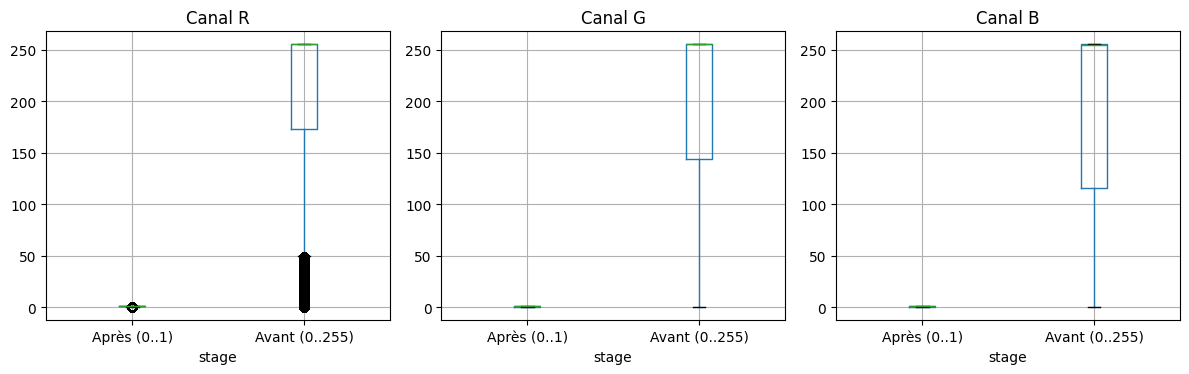

In [11]:
def rgb_flatten(arr):  # arr: (H,W,3)
    r = arr[...,0].ravel()
    g = arr[...,1].ravel()
    b = arr[...,2].ravel()
    return r,g,b

vals_before = {'R':[], 'G':[], 'B':[]}
vals_after  = {'R':[], 'G':[], 'B':[]}

for _, row in sample.iterrows():
    p = path_for(row)
    try:
        o = load_original(p)     # 0..255 uint8
        r,g,b = rgb_flatten(o.astype(np.float32))
        vals_before['R'].extend(r); vals_before['G'].extend(g); vals_before['B'].extend(b)

        z = load_resized_norm(p, (H,W))  # 0..1 float
        r,g,b = rgb_flatten(z)
        vals_after['R'].extend(r); vals_after['G'].extend(g); vals_after['B'].extend(b)
    except Exception:
        pass

import pandas as pd
df_before = pd.DataFrame(vals_before).assign(stage='Avant (0..255)')
df_after  = pd.DataFrame(vals_after).assign(stage='Après (0..1)')
df_rgb = pd.concat([df_before, df_after], ignore_index=True)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1,3, figsize=(12,4), sharey=False)
for i, ch in enumerate(['R','G','B']):
    df_rgb.boxplot(column=ch, by='stage', ax=axes[i])
    axes[i].set_title(f'Canal {ch}')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 6) Code clé (extraits 1–3 lignes)

**Texte — nettoyage :**
```python
from features.text_cleaner import TextCleaner
cleaned = TextCleaner().clean_text("Belle robe <i>noire</i> en coton.")
```

**Texte — TF-IDF :**
```python
from features.text_vectorizer import TextTfidfVectorizer
Xv = TextTfidfVectorizer(ngram_range=(1,2)).fit_transform(cleaned_series)
```

**Images — resize + normalisation :**
```python
arr = np.asarray(Image.open(path).convert('RGB').resize((W,H)), np.float32) / 255.0
```

**Stats images (width/height/occupancy) :**
```python
from features.image_stats import ImageStatsFeaturizer
feat = ImageStatsFeaturizer(image_dir=img_dir).fit_transform(X_train)
```
